# EDA — Datasets de CoffeeMind GT

Exploración de `crop_recommendation.csv` y `coffee_quality.csv`, y construcción de `varieties.csv` a partir de percentiles de altitud y valores agronómicos referenciales.

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 140)

DATA_RAW = Path('../data/raw')

In [2]:
crop = pd.read_csv(DATA_RAW / 'crop_recommendation.csv')
cqi  = pd.read_csv(DATA_RAW / 'coffee_quality.csv')

print(f'crop_recommendation.csv: {crop.shape}')
print(f'coffee_quality.csv:      {cqi.shape}')

crop_recommendation.csv: (2200, 8)
coffee_quality.csv:      (207, 41)


## `crop_recommendation.csv`

Dataset de entrenamiento del Módulo ML; el subset `label == 'coffee'` alimenta las CPTs del Módulo Bayesian.

In [3]:
crop.info()
print('\nNulos por columna:')
print(crop.isna().sum())
print(f'\nDuplicados: {crop.duplicated().sum()}')

<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 137.6 KB

Nulos por columna:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Duplicados: 0


In [4]:
crop.describe().T

,count,mean,std,min,25%,50%,75%,max
N,2200.0,50.551818,36.917334,0.000000,21.000000,37.000000,84.250000,140.000000
P,2200.0,53.362727,32.985883,5.000000,28.000000,51.000000,68.000000,145.000000
K,2200.0,48.149091,50.647931,5.000000,20.000000,32.000000,49.000000,205.000000
temperature,2200.0,25.616244,5.063749,8.825675,22.769375,25.598693,28.561654,43.675493
humidity,2200.0,71.481779,22.263812,14.258040,60.261953,80.473146,89.948771,99.981876
ph,2200.0,6.469480,0.773938,3.504752,5.971693,6.425045,6.923643,9.935091
rainfall,2200.0,103.463655,54.958389,20.211267,64.551686,94.867624,124.267508,298.560117


In [5]:
label_counts = crop['label'].value_counts()
print(f'Total clases: {len(label_counts)}')
print(label_counts)
assert 'coffee' in label_counts.index

Total clases: 22
label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64


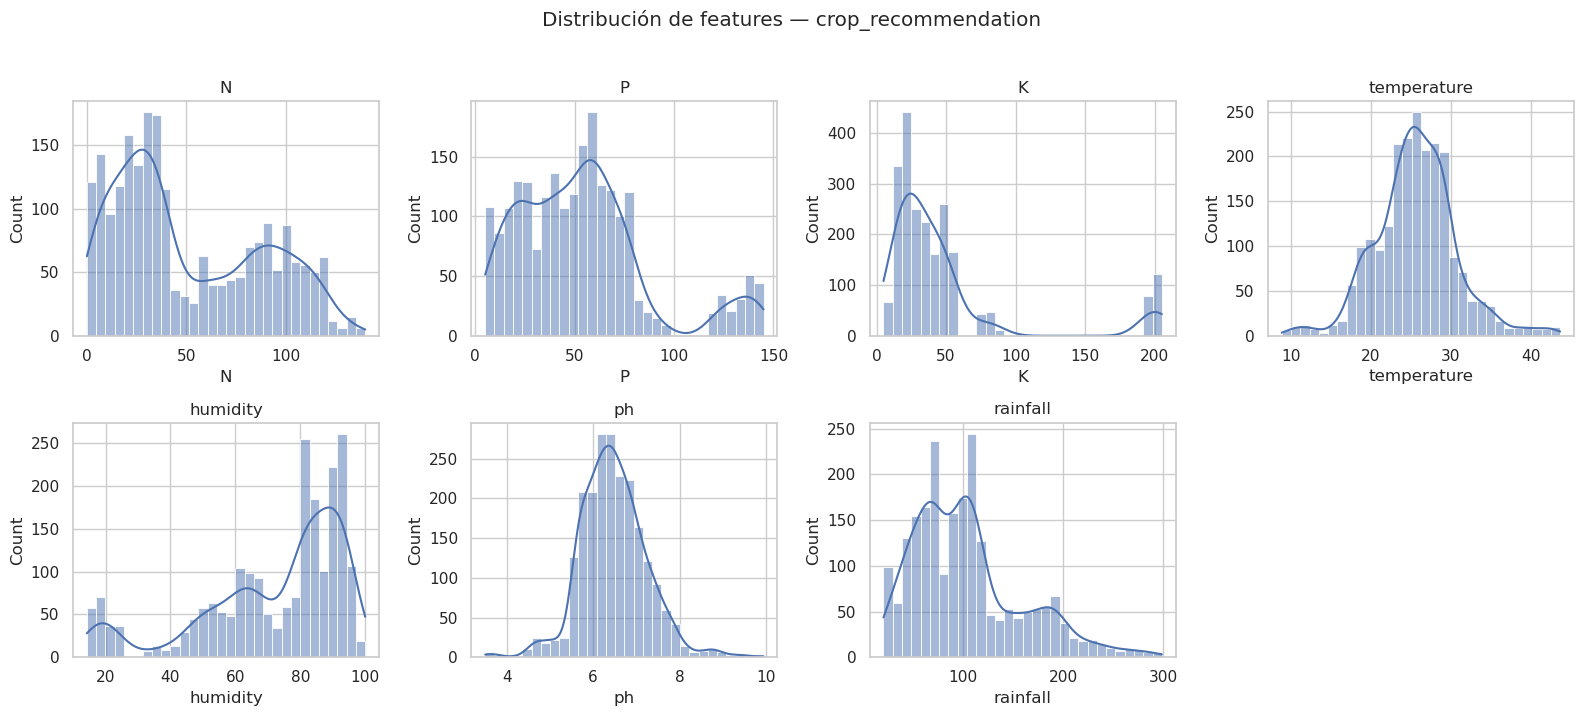

In [6]:
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, features):
    sns.histplot(crop[col], bins=30, ax=ax, kde=True)
    ax.set_title(col)
axes.flat[-1].axis('off')
fig.suptitle('Distribución de features — crop_recommendation', y=1.02)
fig.tight_layout()
plt.show()

In [7]:
crop_coffee = crop[crop['label'] == 'coffee'].copy()
print(f'Filas con label=coffee: {len(crop_coffee)}')
crop_coffee[features].describe().T

Filas con label=coffee: 100


,count,mean,std,min,25%,50%,75%,max
N,100.0,101.200000,12.345203,80.000000,89.000000,103.000000,112.000000,120.000000
P,100.0,28.740000,7.276113,15.000000,23.000000,29.000000,34.250000,40.000000
K,100.0,29.940000,3.246817,25.000000,27.000000,30.000000,33.000000,35.000000
temperature,100.0,25.540477,1.502635,23.059519,24.218563,25.656643,26.744956,27.923744
humidity,100.0,58.869846,5.838566,50.045570,53.814433,57.648083,63.579586,69.948073
ph,100.0,6.790308,0.417132,6.020947,6.429728,6.798626,7.132105,7.493192
rainfall,100.0,158.066295,25.695086,115.156401,136.011746,157.770963,181.472018,199.473564


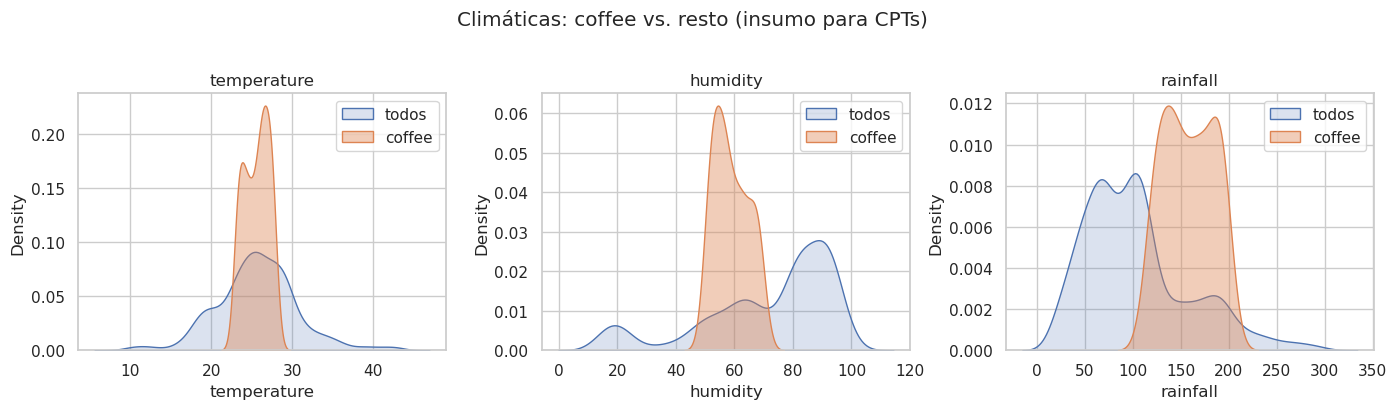

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['temperature', 'humidity', 'rainfall']):
    sns.kdeplot(crop[col], label='todos', ax=ax, fill=True, alpha=0.2)
    sns.kdeplot(crop_coffee[col], label='coffee', ax=ax, fill=True, alpha=0.4)
    ax.set_title(col)
    ax.legend()
fig.suptitle('Climáticas: coffee vs. resto (insumo para CPTs)', y=1.02)
fig.tight_layout()
plt.show()

## `coffee_quality.csv`

Fuente para derivar percentiles de altitud por variedad, filtrando registros de Guatemala.

In [9]:
cqi.info()
print('\nNulos en columnas relevantes:')
print(cqi[['Country of Origin', 'Variety', 'Altitude', 'Total Cup Points']].isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 207 entries, 0 to 206
Data columns (total 41 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             207 non-null    int64  
 1   ID                     207 non-null    int64  
 2   Country of Origin      207 non-null    str    
 3   Farm Name              205 non-null    str    
 4   Lot Number             206 non-null    str    
 5   Mill                   204 non-null    str    
 6   ICO Number             75 non-null     str    
 7   Company                207 non-null    str    
 8   Altitude               206 non-null    str    
 9   Region                 205 non-null    str    
 10  Producer               206 non-null    str    
 11  Number of Bags         207 non-null    int64  
 12  Bag Weight             207 non-null    str    
 13  In-Country Partner     207 non-null    str    
 14  Harvest Year           207 non-null    str    
 15  Grading Date     

In [10]:
country_counts = cqi['Country of Origin'].value_counts()
print(f'Países: {len(country_counts)}')
print(country_counts.head(15))

Países: 22
Country of Origin
Taiwan                          61
Guatemala                       21
Colombia                        19
Honduras                        13
Thailand                        12
Ethiopia                        11
Brazil                          10
Costa Rica                       8
Nicaragua                        7
El Salvador                      7
Tanzania, United Republic Of     6
United States (Hawaii)           5
Peru                             4
Vietnam                          4
Mexico                           4
Name: count, dtype: int64


### Limpieza de `Altitude`

La columna viene como texto. `parse_altitude` promedia rangos del tipo `'1300-1400'`, convierte el resto a `float` y descarta valores fuera de `[100, 3000]` m (el café cultivable de altura llega hasta ~2200 m).

In [11]:
_range_re = re.compile(r'^(\d+(?:\.\d+)?)\s*[-~]\s*(\d+(?:\.\d+)?)$')

def parse_altitude(value):
    if pd.isna(value):
        return np.nan
    s = str(value).strip().lower().replace(',', '').replace('m', '').replace('meters', '').strip()
    m = _range_re.match(s)
    if m:
        val = (float(m.group(1)) + float(m.group(2))) / 2
    else:
        try:
            val = float(s)
        except ValueError:
            return np.nan
    if val < 100 or val > 3000:
        return np.nan
    return val

cqi['altitude_m'] = cqi['Altitude'].apply(parse_altitude)
print(f'Altitudes parseadas: {cqi["altitude_m"].notna().sum()} / {len(cqi)}')
print(cqi['altitude_m'].describe())

Altitudes parseadas: 202 / 207
count     202.000000
mean     1237.378713
std       493.127143
min       139.000000
25%      1000.000000
50%      1300.000000
75%      1596.250000
max      2361.000000
Name: altitude_m, dtype: float64


In [12]:
gt = cqi[cqi['Country of Origin'].str.contains('Guatemala', case=False, na=False)].copy()
print(f'Registros Guatemala: {len(gt)}')
print(f'Con altitud válida: {gt["altitude_m"].notna().sum()}')
print('\nVariedades:')
print(gt['Variety'].value_counts(dropna=False))

Registros Guatemala: 21
Con altitud válida: 18

Variedades:
Variety
Caturra                                                         8
Gesha                                                           4
Bourbon                                                         4
Catuai                                                          1
Typica                                                          1
BOURBON, CATURRA Y CATIMOR                                      1
MARSELLESA, CATUAI, CATURRA & MARSELLESA, ANACAFE 14, CATUAI    1
NaN                                                             1
Name: count, dtype: int64


In [13]:
gt_clean = gt.dropna(subset=['altitude_m', 'Variety'])
alt_stats = gt_clean.groupby('Variety')['altitude_m'].agg(
    n='count',
    p10=lambda x: np.percentile(x, 10),
    p50='median',
    p90=lambda x: np.percentile(x, 90),
    mean='mean',
).sort_values('n', ascending=False)
alt_stats

,n,p10,p50,p90,mean
Variety,,,,,
Caturra,8,1505.0,1600.0,1600.0,1562.5
Gesha,4,1737.6,1900.0,1970.0,1867.0
Bourbon,2,1375.0,1475.0,1575.0,1475.0
"BOURBON, CATURRA Y CATIMOR",1,1400.0,1400.0,1400.0,1400.0
"MARSELLESA, CATUAI, CATURRA & MARSELLESA, ANACAFE 14, CATUAI",1,1302.5,1302.5,1302.5,1302.5
Typica,1,1600.0,1600.0,1600.0,1600.0


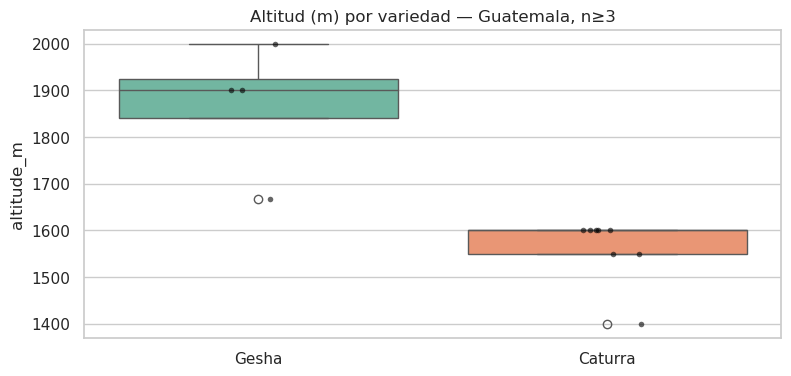

In [14]:
top_varieties = gt_clean['Variety'].value_counts()
shown = top_varieties[top_varieties >= 3].index.tolist()
if shown:
    fig, ax = plt.subplots(figsize=(9, 4))
    sns.boxplot(data=gt_clean[gt_clean['Variety'].isin(shown)],
                x='Variety', y='altitude_m', ax=ax, hue='Variety', palette='Set2', legend=False)
    sns.stripplot(data=gt_clean[gt_clean['Variety'].isin(shown)],
                  x='Variety', y='altitude_m', ax=ax, color='black', size=4, alpha=0.6)
    ax.set_title('Altitud (m) por variedad — Guatemala, n≥3')
    ax.set_xlabel('')
    plt.show()

## Construcción de `varieties.csv`

Tabla de variedades guatemaltecas: dominio del solver CSP y prior de `rust_resistance` para el Módulo Bayesian. Altitudes derivadas de los percentiles del CQI cuando hay muestra suficiente; el resto y todas las demás columnas, de valores agronómicos referenciales (ANACAFE; World Coffee Research Variety Catalog).

| Columna             | Tipo  | Significado                                                       |
| ------------------- | ----- | ----------------------------------------------------------------- |
| `variety`           | str   | Nombre canónico                                                   |
| `alt_min`/`alt_max` | int   | Altitud cultivable en metros sobre el nivel del mar               |
| `ph_min`/`ph_max`   | float | Rango de pH del suelo                                             |
| `shade_required`    | 0/1/2 | 0 = sol tolerante, 1 = semi-sombra, 2 = sombra plena              |
| `rust_resistance`   | 0–10  | Resistencia genética a *Hemileia vastatrix* (0 = ninguna)         |
| `yield_score`       | 0–10  | Potencial productivo relativo                                     |

In [15]:
varieties = pd.DataFrame([
    {'variety': 'Caturra',     'alt_min': 1000, 'alt_max': 1700, 'ph_min': 4.5, 'ph_max': 6.0, 'shade_required': 1, 'rust_resistance': 2, 'yield_score': 6},
    {'variety': 'Bourbon',     'alt_min': 1200, 'alt_max': 2000, 'ph_min': 4.5, 'ph_max': 6.0, 'shade_required': 1, 'rust_resistance': 2, 'yield_score': 5},
    {'variety': 'Catuai',      'alt_min': 800,  'alt_max': 1700, 'ph_min': 5.0, 'ph_max': 6.5, 'shade_required': 1, 'rust_resistance': 2, 'yield_score': 7},
    {'variety': 'Typica',      'alt_min': 1000, 'alt_max': 1800, 'ph_min': 5.0, 'ph_max': 6.0, 'shade_required': 2, 'rust_resistance': 1, 'yield_score': 4},
    {'variety': 'Pache',       'alt_min': 900,  'alt_max': 1700, 'ph_min': 5.0, 'ph_max': 6.0, 'shade_required': 1, 'rust_resistance': 2, 'yield_score': 6},
    {'variety': 'Pacas',       'alt_min': 1000, 'alt_max': 1700, 'ph_min': 5.0, 'ph_max': 6.5, 'shade_required': 1, 'rust_resistance': 2, 'yield_score': 6},
    {'variety': 'Pacamara',    'alt_min': 1100, 'alt_max': 1800, 'ph_min': 5.0, 'ph_max': 6.0, 'shade_required': 1, 'rust_resistance': 2, 'yield_score': 5},
    {'variety': 'Maragogype',  'alt_min': 1000, 'alt_max': 1600, 'ph_min': 5.0, 'ph_max': 6.5, 'shade_required': 1, 'rust_resistance': 1, 'yield_score': 4},
    {'variety': 'Gesha',       'alt_min': 1500, 'alt_max': 2200, 'ph_min': 5.0, 'ph_max': 6.0, 'shade_required': 2, 'rust_resistance': 2, 'yield_score': 4},
    {'variety': 'Catimor',     'alt_min': 600,  'alt_max': 1300, 'ph_min': 5.0, 'ph_max': 6.5, 'shade_required': 0, 'rust_resistance': 8, 'yield_score': 8},
    {'variety': 'Anacafe 14',  'alt_min': 1200, 'alt_max': 1800, 'ph_min': 5.0, 'ph_max': 6.5, 'shade_required': 1, 'rust_resistance': 8, 'yield_score': 8},
    {'variety': 'Marsellesa',  'alt_min': 1000, 'alt_max': 1700, 'ph_min': 5.0, 'ph_max': 6.5, 'shade_required': 1, 'rust_resistance': 8, 'yield_score': 8},
])
varieties

,variety,alt_min,alt_max,ph_min,ph_max,shade_required,rust_resistance,yield_score
0,Caturra,1000,1700,4.5,6.0,1,2,6
1,Bourbon,1200,2000,4.5,6.0,1,2,5
2,Catuai,800,1700,5.0,6.5,1,2,7
3,Typica,1000,1800,5.0,6.0,2,1,4
4,Pache,900,1700,5.0,6.0,1,2,6
5,Pacas,1000,1700,5.0,6.5,1,2,6
6,Pacamara,1100,1800,5.0,6.0,1,2,5
7,Maragogype,1000,1600,5.0,6.5,1,1,4
8,Gesha,1500,2200,5.0,6.0,2,2,4
9,Catimor,600,1300,5.0,6.5,0,8,8


In [18]:
assert (varieties['alt_min'] < varieties['alt_max']).all()
assert (varieties['ph_min'] < varieties['ph_max']).all()
assert varieties['shade_required'].isin([0, 1, 2]).all()
assert varieties['rust_resistance'].between(0, 10).all()
assert varieties['yield_score'].between(0, 10).all()
assert varieties['variety'].is_unique
print(f'[OK] {len(varieties)} variedades')

[OK] 12 variedades


In [17]:
# Cotejo: los rangos en varieties.csv ¿contienen las altitudes observadas en CQI Guatemala?
rows = []
for variety in varieties['variety']:
    sub = gt_clean[gt_clean['Variety'].str.lower() == variety.lower()]
    if len(sub) == 0:
        continue
    vrow = varieties[varieties['variety'] == variety].iloc[0]
    obs = sub['altitude_m']
    rows.append({
        'variety': variety,
        'n_cqi': len(sub),
        'obs_min': obs.min(),
        'obs_max': obs.max(),
        'csv_alt_min': vrow['alt_min'],
        'csv_alt_max': vrow['alt_max'],
        'covered': bool(vrow['alt_min'] <= obs.min() and obs.max() <= vrow['alt_max']),
    })
pd.DataFrame(rows)

,variety,n_cqi,obs_min,obs_max,csv_alt_min,csv_alt_max,covered
0,Caturra,8,1400.0,1600.0,1000,1700,True
1,Bourbon,2,1350.0,1600.0,1200,2000,True
2,Typica,1,1600.0,1600.0,1000,1800,True
3,Gesha,4,1668.0,2000.0,1500,2200,True


In [19]:
out_path = DATA_RAW / 'varieties.csv'
varieties.to_csv(out_path, index=False)
print(f'Guardado: {out_path.resolve()}')
pd.read_csv(out_path).head()

Guardado: /home/tunchxz/github/CC3085-Proyecto-Final/data/raw/varieties.csv


,variety,alt_min,alt_max,ph_min,ph_max,shade_required,rust_resistance,yield_score
0,Caturra,1000,1700,4.5,6.0,1,2,6
1,Bourbon,1200,2000,4.5,6.0,1,2,5
2,Catuai,800,1700,5.0,6.5,1,2,7
3,Typica,1000,1800,5.0,6.0,2,1,4
4,Pache,900,1700,5.0,6.0,1,2,6
